### *Financial Analysis*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

# 1) Load the CSV
file_path = "finance_economics_dataset.csv"
df = pd.read_csv(file_path, low_memory=False)

Saving finance_economics_dataset.csv to finance_economics_dataset.csv


In [ ]:
# 1. What is the shape of the dataset?
print("Shape of the dataset (rows, columns):", df.shape)

Shape of the dataset (rows, columns): (3000, 24)


In [ ]:
# 2. What are the column names and their data types?
print("Column names and their data types:\n")
print(df.dtypes)

Column names and their data types:

Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)       

In [ ]:
# 3. How many unique stock indices are there?
unique_indices = df['Stock Index'].nunique()
index_names = df['Stock Index'].unique()

print(f"Number of unique stock indices: {unique_indices}")

Number of unique stock indices: 3


In [ ]:
# 4. What is the date range of the dataset?
start_date = df['Date'].min()
end_date = df['Date'].max()

print(f"Date range of the dataset: {start_date.date()} to {end_date.date()}")

Date range of the dataset: 2000-01-01 to 2008-03-18


In [ ]:
# 5. Are there any missing values?
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Fundin

In [ ]:
# 6. Are there negative values in columns that should be non-negative?
# Identify columns that should be non-negative
nonneg_keywords = ['price', 'volume', 'gdp', 'profit', 'index', 'confidence']
nonneg_cols = [c for c in df.columns if any(k in c.lower() for k in nonneg_keywords)]

# Check for negative values in those columns
negatives = {}
for col in nonneg_cols:
    if np.issubdtype(df[col].dropna().dtype, np.number):  # Only numeric columns
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            negatives[col] = int(neg_count)

print("Columns with negative values that should be non-negative:\n")
print(negatives if negatives else "No invalid negative values found.")


Columns with negative values that should be non-negative:

{'GDP Growth (%)': 947}


In [ ]:
# 7. What is the summary of GDP Growth (%)?
# Find the GDP Growth column
gdp_col = None
for col in df.columns:
    if "gdp" in col.lower() and "growth" in col.lower():
        gdp_col = col
        break

# Display summary statistics for GDP Growth (%)
if gdp_col:
    gdp_summary = df[gdp_col].describe()
    print(f"Summary of {gdp_col}:\n")
    print(gdp_summary)
else:
    print("GDP Growth column not found in the dataset.")

Summary of GDP Growth (%):

count    3000.000000
mean        2.608903
std         4.287337
min        -5.000000
25%        -1.012500
50%         2.725000
75%         6.242500
max        10.000000
Name: GDP Growth (%), dtype: float64


In [ ]:
# 8. Are there rows with zero or near-zero trading volume?
# Identify the trading volume column
volume_col = None
for col in df.columns:
    if "volume" in col.lower() or "trading" in col.lower():
        volume_col = col
        break

# Check for zero or near-zero trading volume
if volume_col:
    zero_volume_rows = df[df[volume_col] <= 1]
    zero_volume_count = zero_volume_rows.shape[0]

    print(f"Number of rows with zero or near-zero trading volume: {zero_volume_count}")
    if zero_volume_count > 0:
        print("\nSample rows with zero/near-zero volume:")
        print(zero_volume_rows.head())
else:
    print("Trading Volume column not found in the dataset.")

Number of rows with zero or near-zero trading volume: 0


In [ ]:
# 9. Are there any duplicate rows?
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [ ]:
# 10. Are there outliers in GDP, Gold, or Oil prices?
# Helper function to find outliers using IQR
def find_outliers(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (s < lower_bound) | (s > upper_bound)
    return {
        "count": outlier_mask.sum(),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "min_value": s.min(),
        "max_value": s.max()
    }

# Identify relevant columns
gdp_col = next((c for c in df.columns if "gdp" in c.lower()), None)
gold_col = next((c for c in df.columns if "gold" in c.lower()), None)
oil_col = next((c for c in df.columns if "oil" in c.lower()), None)

# Apply outlier detection
outlier_summary = {}
for col in [gdp_col, gold_col, oil_col]:
    if col:
        outlier_summary[col] = find_outliers(df[col])

# Display results
for col, stats in outlier_summary.items():
    print(f"\nOutlier summary for '{col}':")
    for key, val in stats.items():
        print(f"  {key}: {val}")


Outlier summary for 'GDP Growth (%)':
  count: 0
  lower_bound: -11.895
  upper_bound: 17.125
  min_value: -5.0
  max_value: 10.0

Outlier summary for 'Gold Price (USD per Ounce)':
  count: 0
  lower_bound: -54.25125000000003
  upper_bound: 3361.71875
  min_value: 800.16
  max_value: 2499.66

Outlier summary for 'Crude Oil Price (USD per Barrel)':
  count: 0
  lower_bound: -47.25
  upper_bound: 218.99
  min_value: 20.04
  max_value: 149.87


In [ ]:
# 11. What is the summary of Inflation Rate (%)?
# Identify the inflation column
inflation_col = None
for col in df.columns:
    if "inflation" in col.lower() or "cpi" in col.lower():
        inflation_col = col
        break

# Display summary statistics
if inflation_col:
    inflation_summary = df[inflation_col].describe()
    print(f"Summary of {inflation_col}:\n")
    print(inflation_summary)
else:
    print("Inflation Rate column not found in the dataset.")

Summary of Inflation Rate (%):

count    3000.000000
mean        5.096830
std         2.910513
min         0.010000
25%         2.607500
50%         5.110000
75%         7.600000
max        10.000000
Name: Inflation Rate (%), dtype: float64


In [ ]:
# 12. What is the average unemployment rate?
# Identify the unemployment column
unemp_col = None
for col in df.columns:
    if "unemployment" in col.lower():
        unemp_col = col
        break

# Compute average unemployment rate
if unemp_col:
    avg_unemployment = df[unemp_col].mean()
    print(f"Average Unemployment Rate (%): {avg_unemployment:.2f}")
else:
    print("Unemployment Rate column not found in the dataset.")

Average Unemployment Rate (%): 8.66


In [ ]:
# 13. Which index has the highest trading volume?
# Identify relevant columns
index_col = None
volume_col = None

for col in df.columns:
    if "index" in col.lower() or "stock" in col.lower():
        index_col = col
    if "volume" in col.lower() or "trading" in col.lower():
        volume_col = col

# Find the index with the highest total trading volume
if index_col and volume_col:
    volume_sum = df.groupby(index_col)[volume_col].sum().sort_values(ascending=False)
    top_index = volume_sum.idxmax()
    top_volume = volume_sum.max()

    print(f"Index with the highest trading volume: {top_index}")
    print(f"Total trading volume: {top_volume:,.0f}")
else:
    print("Index or Trading Volume column not found in the dataset.")

Index with the highest trading volume: 293.3
Total trading volume: 1,985,915,042


In [ ]:
# 14. How many stock records are from each index?
# Identify the index column
index_col = None
for col in df.columns:
    if "index" in col.lower() or "stock" in col.lower():
        index_col = col
        break

# Count records per index
if index_col:
    records_per_index = df[index_col].value_counts()
    print("Number of stock records from each index:\n")
    print(records_per_index)
else:
    print("Index column not found in the dataset.")

Number of stock records from each index:

Stock Index
S&P 500      1036
NASDAQ       1007
Dow Jones     957
Name: count, dtype: int64


       Inflation Rate (%)  Interest Rate (%)
count         3000.000000        3000.000000
mean             5.096830           5.218237
std              2.910513           2.726115
min              0.010000           0.500000
25%              2.607500           2.890000
50%              5.110000           5.250000
75%              7.600000           7.492500
max             10.000000          10.000000
Correlation between Inflation Rate and Interest Rate: 0.00573292723557624


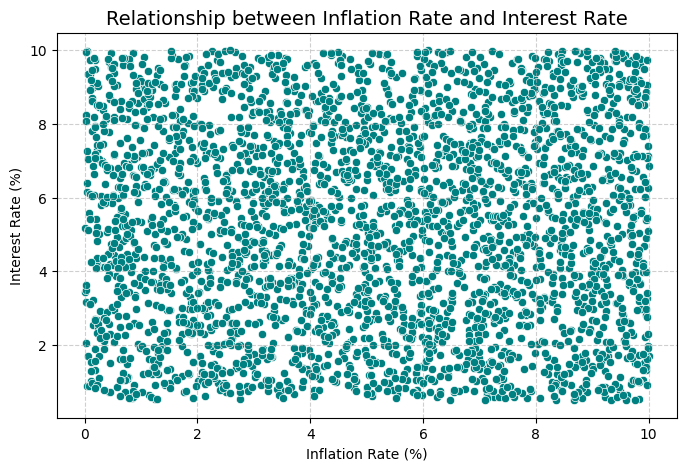

In [ ]:
# 15. What is the correlation between inflation and interest rate?
# Display the relevant columns
df[['Inflation Rate (%)', 'Interest Rate (%)']].head()

# Drop missing values in the relevant columns
df_clean = df.dropna(subset=['Inflation Rate (%)', 'Interest Rate (%)'])

# Summary statistics
print(df_clean[['Inflation Rate (%)', 'Interest Rate (%)']].describe())

# Compute the Pearson correlation
corr = df_clean['Inflation Rate (%)'].corr(df_clean['Interest Rate (%)'])
print("Correlation between Inflation Rate and Interest Rate:", corr)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_clean,
    x='Inflation Rate (%)',
    y='Interest Rate (%)',
    color='teal'
)
plt.title('Relationship between Inflation Rate and Interest Rate', fontsize=14)
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Interest Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# 16. What is the average Consumer Confidence Index?
# Calculate the mean
avg_cci = df_clean['Consumer Confidence Index'].mean()
print("Average Consumer Confidence Index:", round(avg_cci, 2))

Average Consumer Confidence Index: 85.04


In [ ]:
# 17. Which column has the highest standard deviation?
# Identify the column with the highest standard deviation
max_std_column = std_values.idxmax()
max_std_value = std_values.max()

print("Column with the highest standard deviation:", max_std_column)
print("Standard Deviation Value:", round(max_std_value, 2))

Column with the highest standard deviation: Trading Volume
Standard Deviation Value: 285900426.37


In [ ]:
# 18. What is the highest gold price recorded?
# Find the highest gold price
highest_gold_price = df['Gold Price (USD per Ounce)'].max()

print("Highest Gold Price Recorded (USD per Ounce):", highest_gold_price)

Highest Gold Price Recorded (USD per Ounce): 2499.66


In [ ]:
# 19. Which date had the highest crude oil price?
# Find the row with the highest crude oil price
highest_oil_row = df.loc[df['Crude Oil Price (USD per Barrel)'].idxmax(), ['Date', 'Crude Oil Price (USD per Barrel)']]

print("Date with Highest Crude Oil Price:", highest_oil_row['Date'])
print("Highest Crude Oil Price (USD per Barrel):", highest_oil_row['Crude Oil Price (USD per Barrel)'])


Date with Highest Crude Oil Price: 22-11-2001
Highest Crude Oil Price (USD per Barrel): 149.87


In [ ]:
# 20. What is the average corporate profit?
avg_corporate_profit = df['Corporate Profits (Billion USD)'].mean()
print("Average Corporate Profit (in Billion USD):", round(avg_corporate_profit, 2))

Average Corporate Profit (in Billion USD): 2553.76


In [ ]:
# Insightful Analysis Questions :

In [ ]:
# 1. What percentage of the dataset shows negative GDP growth?
# Import required libraries
import pandas as pd
# Count total and negative GDP growth records
total_rows = len(df)
negative_gdp_rows = (df['GDP Growth (%)'] < 0).sum()

# Calculate percentage
negative_gdp_percent = (negative_gdp_rows / total_rows) * 100
print("Percentage of Negative GDP Growth Records:", round(negative_gdp_percent, 2), "%")

Percentage of Negative GDP Growth Records: 31.57 %


In [ ]:
# ---------- Common header (run once) ----------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

plt.rcParams["figure.figsize"] = (8,4)

# load dataset (put CSV in same folder)
df = pd.read_csv("finance_economics_dataset.csv")
print("Loaded:", len(df), "rows. Columns:", list(df.columns))

# small helper to find best-match column by keywords (case-insensitive substring)
def find_column(df, keywords):
    cols = list(df.columns)
    cols_lower = [c.lower() for c in cols]
    for kw in keywords:
        kw = kw.lower()
        for i,c in enumerate(cols_lower):
            if kw in c:
                return cols[i]
    # fallback: try any token of keywords
    for kw in keywords:
        token = kw.lower().split()[0]
        for i,c in enumerate(cols_lower):
            if token in c:
                return cols[i]
    return None

# convert numeric safely helper
def to_num(s):
    return pd.to_numeric(s, errors='coerce')


Loaded: 3000 rows. Columns: ['Date', 'Stock Index', 'Open Price', 'Close Price', 'Daily High', 'Daily Low', 'Trading Volume', 'GDP Growth (%)', 'Inflation Rate (%)', 'Unemployment Rate (%)', 'Interest Rate (%)', 'Consumer Confidence Index', 'Government Debt (Billion USD)', 'Corporate Profits (Billion USD)', 'Forex USD/EUR', 'Forex USD/JPY', 'Crude Oil Price (USD per Barrel)', 'Gold Price (USD per Ounce)', 'Real Estate Index', 'Retail Sales (Billion USD)', 'Bankruptcy Rate (%)', 'Mergers & Acquisitions Deals', 'Venture Capital Funding (Billion USD)', 'Consumer Spending (Billion USD)']


Using 'Inflation Rate (%)' and 'Interest Rate (%)'. Correlation = 0.0057 (positive -> inflation ↑ linked to interest ↑)


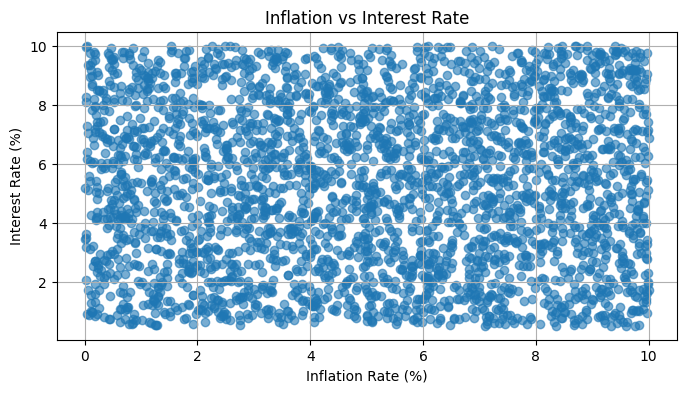

In [ ]:
# 2. Does high inflation correspond to higher interest rates?
infl_cols = ["inflation", "cpi", "inflation_rate", "inflation (%)"]
int_cols  = ["interest", "interest_rate", "interest rate", "policy_rate", "repo_rate"]
infl_col = find_column(df, infl_cols)
int_col  = find_column(df, int_cols)
if infl_col is None or int_col is None:
    print("Missing column. inflation:", infl_col, "interest:", int_col)
else:
    infl = to_num(df[infl_col])
    ir   = to_num(df[int_col])
    common = infl.dropna().index.intersection(ir.dropna().index)
    corr = infl.loc[common].corr(ir.loc[common])
    print(f"Using '{infl_col}' and '{int_col}'. Correlation = {corr:.4f} (positive -> inflation ↑ linked to interest ↑)")
    plt.scatter(infl, ir, alpha=0.6)
    plt.xlabel(infl_col); plt.ylabel(int_col); plt.title("Inflation vs Interest Rate"); plt.grid(True)
    plt.show()


Using 'Unemployment Rate (%)' and 'Consumer Spending (Billion USD)'. Correlation = 0.0188 (negative -> higher unemployment relates to lower spending)


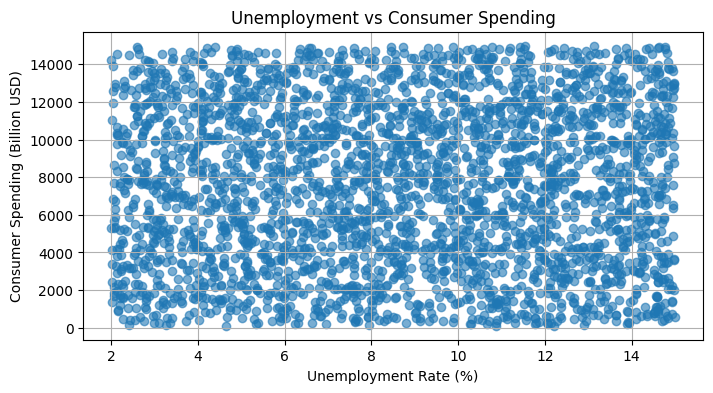

In [ ]:
# 3. Is there a relationship between unemployment and consumer spending?
unemp_cols = ["unemployment", "unemployment_rate", "unemp", "unemployment (%)"]
cons_cols   = ["consumer_spending", "consumption", "retail_sales", "consumer spending", "consumer_spend"]
unemp_col = find_column(df, unemp_cols)
cons_col  = find_column(df, cons_cols)
if unemp_col is None or cons_col is None:
    print("Missing column. unemployment:", unemp_col, "consumer_spending:", cons_col)
else:
    u = to_num(df[unemp_col])
    c = to_num(df[cons_col])
    common = u.dropna().index.intersection(c.dropna().index)
    corr = u.loc[common].corr(c.loc[common])
    print(f"Using '{unemp_col}' and '{cons_col}'. Correlation = {corr:.4f} (negative -> higher unemployment relates to lower spending)")
    plt.scatter(u, c, alpha=0.6)
    plt.xlabel(unemp_col); plt.ylabel(cons_col); plt.title("Unemployment vs Consumer Spending"); plt.grid(True)
    plt.show()


Using 'Corporate Profits (Billion USD)' and 'Consumer Confidence Index'. Correlation = 0.0180


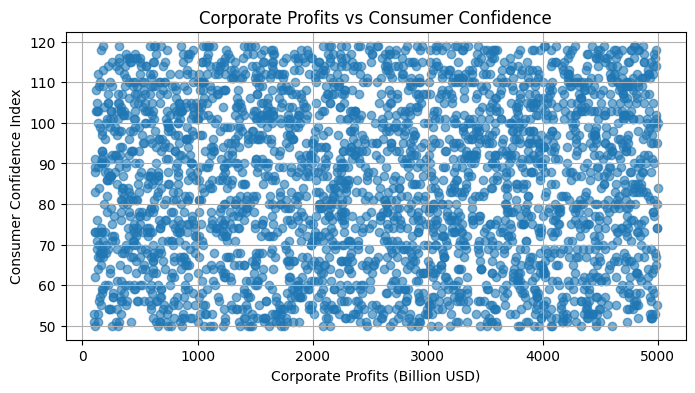

In [ ]:
# 4. Do higher corporate profits align with higher consumer confidence?
# Q4
corp_cols = ["corporate_profit", "corporate_profits", "profits", "profit_before_tax", "corp_profit"]
conf_cols = ["consumer_confidence", "confidence_index", "consumer sentiment", "cci"]
corp_col = find_column(df, corp_cols)
conf_col = find_column(df, conf_cols)
if corp_col is None or conf_col is None:
    print("Missing column. corporate_profits:", corp_col, "consumer_confidence:", conf_col)
else:
    corp = to_num(df[corp_col])
    conf = to_num(df[conf_col])
    common = corp.dropna().index.intersection(conf.dropna().index)
    corr = corp.loc[common].corr(conf.loc[common])
    print(f"Using '{corp_col}' and '{conf_col}'. Correlation = {corr:.4f}")
    plt.scatter(corp, conf, alpha=0.6)
    plt.xlabel(corp_col); plt.ylabel(conf_col); plt.title("Corporate Profits vs Consumer Confidence"); plt.grid(True)
    plt.show()


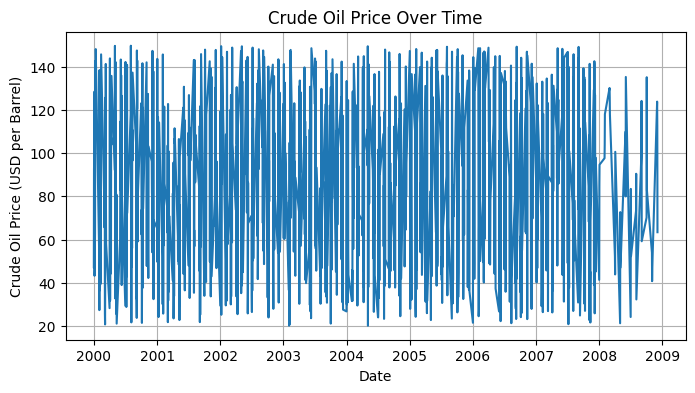

In [ ]:
# 5. What’s the trend of crude oil prices over time?
date_col = find_column(df, ["date", "year", "period", "time", "month"])
oil_cols = ["crude", "oil_price", "crude_oil", "brent", "wti", "oil price"]
oil_col = find_column(df, oil_cols)
if oil_col is None:
    print("Oil price column not found. Tried:", oil_cols)
else:
    if date_col:
        # try parse date
        df2 = df.copy()
        df2[date_col] = pd.to_datetime(df2[date_col], errors='coerce')
        df2 = df2.sort_values(by=date_col)
        plt.plot(df2[date_col], to_num(df2[oil_col]))
        plt.xlabel(date_col); plt.ylabel(oil_col); plt.title("Crude Oil Price Over Time"); plt.grid(True)
        plt.show()
    else:
        print("No date column found. Plotting oil price by row index.")
        plt.plot(to_num(df[oil_col]))
        plt.xlabel("Row index"); plt.ylabel(oil_col); plt.title("Crude Oil Price (index order)"); plt.grid(True)
        plt.show()


Using 'Gold Price (USD per Ounce)' and 'Close Price'. Correlation = -0.0145 (negative -> inverse relationship)


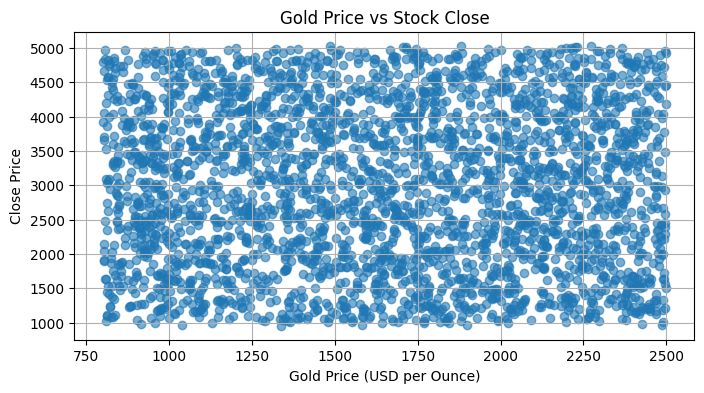

In [ ]:
# 6. Are gold prices inversely related to stock performance?
gold_cols = ["gold", "gold_price", "gold_price_usd"]
stock_cols = ["close", "closing_price", "stock_close", "index_close", "close_price"]
gold_col = find_column(df, gold_cols)
stock_col = find_column(df, stock_cols)
if gold_col is None or stock_col is None:
    print("Missing column. gold:", gold_col, "stock_close:", stock_col)
else:
    g = to_num(df[gold_col])
    s = to_num(df[stock_col])
    common = g.dropna().index.intersection(s.dropna().index)
    corr = g.loc[common].corr(s.loc[common])
    print(f"Using '{gold_col}' and '{stock_col}'. Correlation = {corr:.4f} (negative -> inverse relationship)")
    plt.scatter(g, s, alpha=0.6)
    plt.xlabel(gold_col); plt.ylabel(stock_col); plt.title("Gold Price vs Stock Close"); plt.grid(True)
    plt.show()


Using 'Government Debt (Billion USD)' and 'Consumer Confidence Index'. Correlation = -0.0364


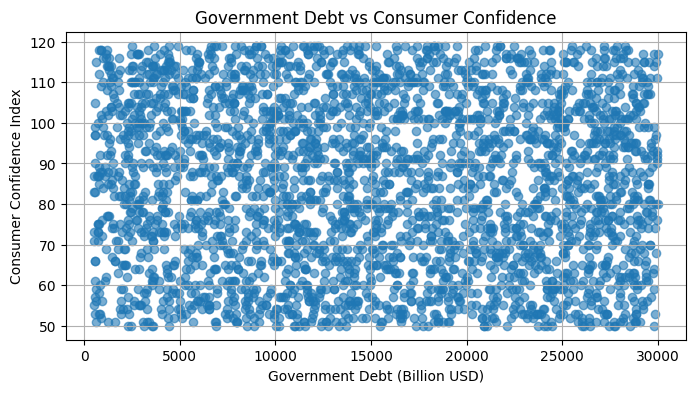

In [ ]:
# 7. Does government debt impact consumer confidence?
gov_cols = ["government_debt", "debt", "public_debt", "gov_debt", "debt_to_gdp"]
conf_cols = ["consumer_confidence", "confidence_index", "consumer sentiment", "cci"]
gov_col = find_column(df, gov_cols)
conf_col = find_column(df, conf_cols)
if gov_col is None or conf_col is None:
    print("Missing column. government_debt:", gov_col, "consumer_confidence:", conf_col)
else:
    gov = to_num(df[gov_col])
    conf = to_num(df[conf_col])
    common = gov.dropna().index.intersection(conf.dropna().index)
    corr = gov.loc[common].corr(conf.loc[common])
    print(f"Using '{gov_col}' and '{conf_col}'. Correlation = {corr:.4f}")
    plt.scatter(gov, conf, alpha=0.6)
    plt.xlabel(gov_col); plt.ylabel(conf_col); plt.title("Government Debt vs Consumer Confidence"); plt.grid(True)
    plt.show()


Using 'Mergers & Acquisitions Deals' and 'Close Price'. Correlation = 0.0026


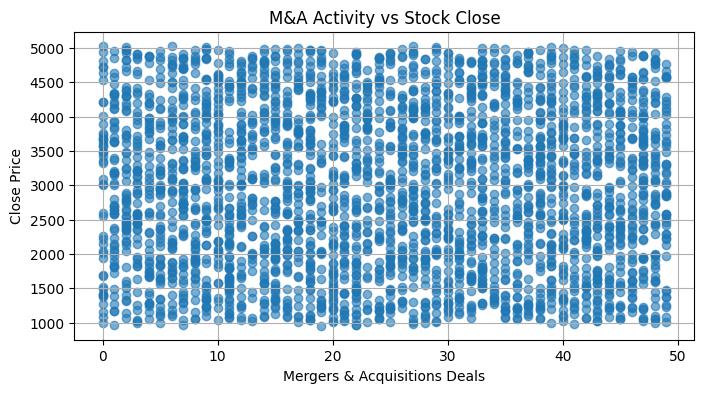

In [ ]:
# 8. How do mergers & acquisitions (M&A) activity correlate with stock index closing prices?
ma_cols = ["m&a", "ma_activity", "mergers", "acquisitions", "m_and_a"]
stock_cols = ["close", "closing_price", "stock_close", "index_close", "close_price"]
ma_col = find_column(df, ma_cols)
stock_col = find_column(df, stock_cols)
if ma_col is None or stock_col is None:
    print("Missing column. M&A:", ma_col, "stock_close:", stock_col)
else:
    ma = to_num(df[ma_col])
    s = to_num(df[stock_col])
    common = ma.dropna().index.intersection(s.dropna().index)
    corr = ma.loc[common].corr(s.loc[common])
    print(f"Using '{ma_col}' and '{stock_col}'. Correlation = {corr:.4f}")
    plt.scatter(ma, s, alpha=0.6)
    plt.xlabel(ma_col); plt.ylabel(stock_col); plt.title("M&A Activity vs Stock Close"); plt.grid(True)
    plt.show()


Using 'Retail Sales (Billion USD)' and 'GDP Growth (%)'. Correlation = -0.0143


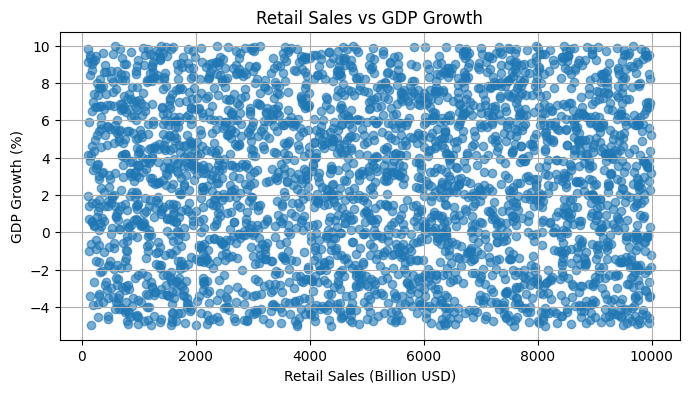

In [ ]:
# 9. Is retail sales growth associated with GDP growth?
retail_cols = ["retail_sales", "retailsales", "retail", "retail_sales_growth"]
gdp_cols = ["gdp", "gdp_growth", "gdp growth", "gdp (%)", "gdp_rate"]
ret_col = find_column(df, retail_cols)
gdp_col = find_column(df, gdp_cols)
if ret_col is None or gdp_col is None:
    print("Missing column. retail:", ret_col, "gdp:", gdp_col)
else:
    r = to_num(df[ret_col])
    g = to_num(df[gdp_col])
    common = r.dropna().index.intersection(g.dropna().index)
    corr = r.loc[common].corr(g.loc[common])
    print(f"Using '{ret_col}' and '{gdp_col}'. Correlation = {corr:.4f}")
    plt.scatter(r, g, alpha=0.6)
    plt.xlabel(ret_col); plt.ylabel(gdp_col); plt.title("Retail Sales vs GDP Growth"); plt.grid(True)
    plt.show()


Using 'Close Price' and 'Consumer Spending (Billion USD)'. Correlation = 0.0004


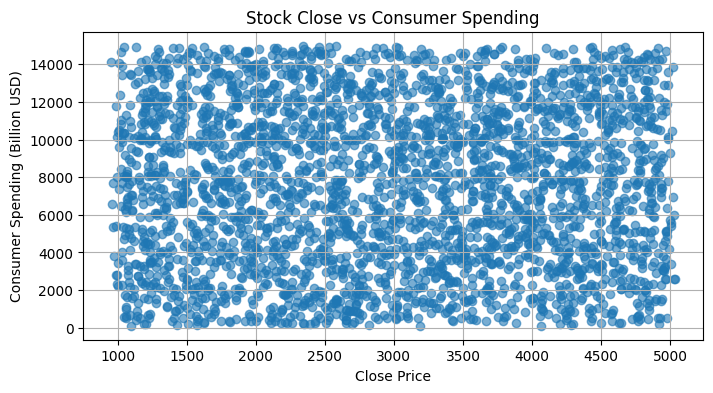

In [ ]:
# 10. Is stock market performance linked to consumer spending?
stock_cols = ["close", "closing_price", "stock_close", "index_close", "close_price"]
cons_cols  = ["consumer_spending", "consumption", "retail_sales", "consumer spending"]
stock_col = find_column(df, stock_cols)
cons_col  = find_column(df, cons_cols)
if stock_col is None or cons_col is None:
    print("Missing column. stock_close:", stock_col, "consumer_spending:", cons_col)
else:
    s = to_num(df[stock_col])
    c = to_num(df[cons_col])
    common = s.dropna().index.intersection(c.dropna().index)
    corr = s.loc[common].corr(c.loc[common])
    print(f"Using '{stock_col}' and '{cons_col}'. Correlation = {corr:.4f}")
    plt.scatter(s, c, alpha=0.6)
    plt.xlabel(stock_col); plt.ylabel(cons_col); plt.title("Stock Close vs Consumer Spending"); plt.grid(True)
    plt.show()


In [ ]:
# 11. Which stock index had the highest average closing price?
index_cols = ["index", "index_name", "ticker", "stock_index", "symbol"]
close_cols = ["close", "closing_price", "stock_close", "index_close", "close_price"]
index_col = find_column(df, index_cols)
close_col = find_column(df, close_cols)
if index_col is None or close_col is None:
    print("Missing column. index:", index_col, "close:", close_col)
else:
    # compute average closing price by index/ticker
    df_tmp = df[[index_col, close_col]].copy()
    df_tmp[close_col] = to_num(df_tmp[close_col])
    grouped = df_tmp.groupby(index_col)[close_col].mean().dropna().sort_values(ascending=False)
    print("Top 10 indices by average closing price:")
    print(grouped.head(10))
    if not grouped.empty:
        print("Highest average close:", grouped.index[0], grouped.iloc[0])


Top 10 indices by average closing price:
Stock Index
Dow Jones    3004.456447
NASDAQ       2985.905015
S&P 500      2955.286052
Name: Close Price, dtype: float64
Highest average close: Dow Jones 3004.45644723093


Using 'Interest Rate (%)' and 'Unemployment Rate (%)'. Correlation = 0.0180


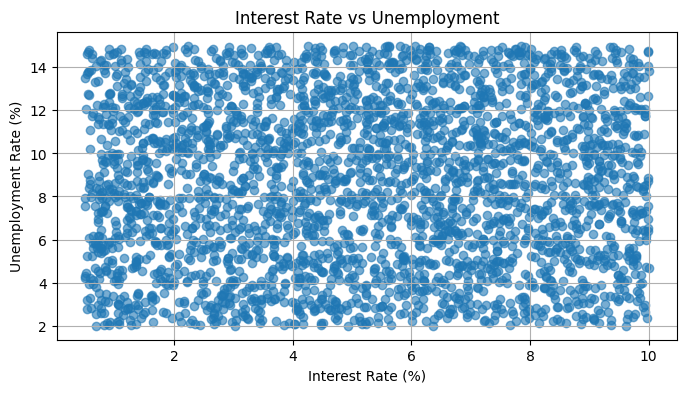

In [ ]:
# 12. What is the relationship between interest rate and unemployment?
int_cols = ["interest", "interest_rate", "interest rate", "policy_rate", "repo_rate"]
unemp_cols = ["unemployment", "unemployment_rate", "unemp", "unemployment (%)"]
int_col = find_column(df, int_cols)
unemp_col = find_column(df, unemp_cols)
if int_col is None or unemp_col is None:
    print("Missing column. interest:", int_col, "unemployment:", unemp_col)
else:
    ir = to_num(df[int_col])
    u  = to_num(df[unemp_col])
    common = ir.dropna().index.intersection(u.dropna().index)
    corr = ir.loc[common].corr(u.loc[common])
    print(f"Using '{int_col}' and '{unemp_col}'. Correlation = {corr:.4f}")
    plt.scatter(ir, u, alpha=0.6)
    plt.xlabel(int_col); plt.ylabel(unemp_col); plt.title("Interest Rate vs Unemployment"); plt.grid(True)
    plt.show()


Using 'Consumer Confidence Index' and 'Bankruptcy Rate (%)'. Correlation = -0.0163 (negative -> lower confidence with higher bankruptcies)


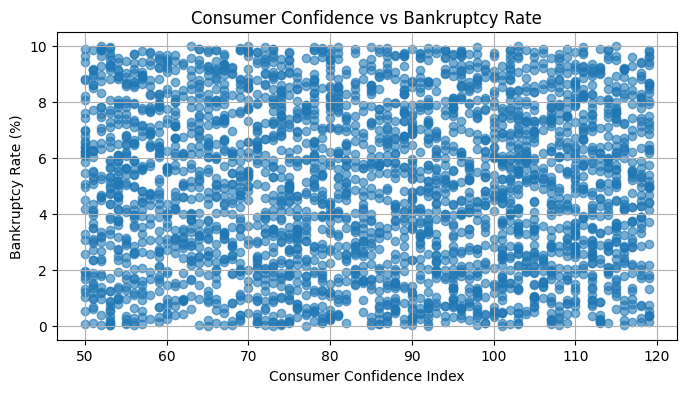

In [ ]:
# 13. Do lower consumer confidence values coincide with higher bankruptcy rates?
conf_cols = ["consumer_confidence", "confidence_index", "consumer sentiment", "cci"]
bank_cols = ["bankruptcy", "bankruptcies", "bankruptcy_rate", "bankruptcy_rate (%)"]
conf_col = find_column(df, conf_cols)
bank_col = find_column(df, bank_cols)
if conf_col is None or bank_col is None:
    print("Missing column. consumer_confidence:", conf_col, "bankruptcy:", bank_col)
else:
    conf = to_num(df[conf_col])
    bank = to_num(df[bank_col])
    common = conf.dropna().index.intersection(bank.dropna().index)
    corr = conf.loc[common].corr(bank.loc[common])
    print(f"Using '{conf_col}' and '{bank_col}'. Correlation = {corr:.4f} (negative -> lower confidence with higher bankruptcies)")
    plt.scatter(conf, bank, alpha=0.6)
    plt.xlabel(conf_col); plt.ylabel(bank_col); plt.title("Consumer Confidence vs Bankruptcy Rate"); plt.grid(True)
    plt.show()


In [ ]:
# 14. Which indicator has the highest correlation with stock close price?
stock_cols = ["close", "closing_price", "stock_close", "index_close", "close_price"]
stock_col = find_column(df, stock_cols)
if stock_col is None:
    print("Stock close column not found. Tried:", stock_cols)
else:
    # compute absolute correlations with all other numeric columns
    corrs = {}
    stock_series = to_num(df[stock_col])
    for c in df.columns:
        if c == stock_col: continue
        s = to_num(df[c])
        common = stock_series.dropna().index.intersection(s.dropna().index)
        if len(common) >= 5:
            try:
                val = stock_series.loc[common].corr(s.loc[common])
                if pd.notna(val):
                    corrs[c] = abs(val)
            except Exception:
                pass
    if not corrs:
        print("No numeric candidate columns with enough overlap found.")
    else:
        sorted_corrs = sorted(corrs.items(), key=lambda x: x[1], reverse=True)
        print("Top 10 indicators by absolute correlation with stock close:")
        for k,v in sorted_corrs[:10]:
            print(f"  {k}: |corr| = {v:.4f}")
        best = sorted_corrs[0]
        print(f"Highest correlated indicator: {best[0]} with |corr| = {best[1]:.4f}")


Top 10 indicators by absolute correlation with stock close:
  Daily High: |corr| = 0.9998
  Daily Low: |corr| = 0.9998
  Open Price: |corr| = 0.9997
  Retail Sales (Billion USD): |corr| = 0.0494
  Forex USD/EUR: |corr| = 0.0294
  Bankruptcy Rate (%): |corr| = 0.0294
  Venture Capital Funding (Billion USD): |corr| = 0.0214
  Interest Rate (%): |corr| = 0.0204
  Trading Volume: |corr| = 0.0163
  Forex USD/JPY: |corr| = 0.0160
Highest correlated indicator: Daily High with |corr| = 0.9998


Using 'Corporate Profits (Billion USD)' and 'Unemployment Rate (%)'. Correlation = 0.0083 (negative -> higher profits linked to lower unemployment)


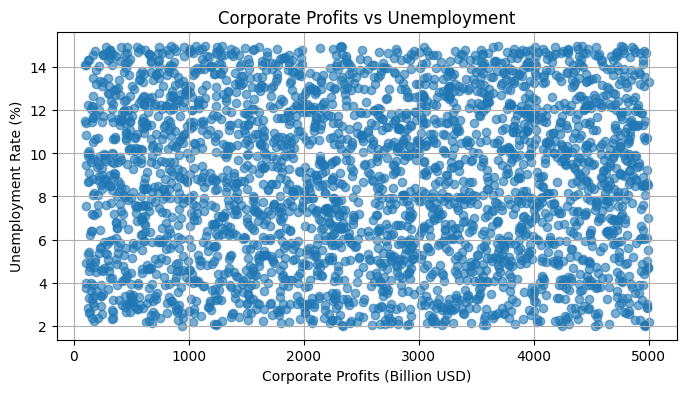

In [ ]:
# 15. Are unemployment rates lower when corporate profits are high?
corp_cols = ["corporate_profit", "corporate_profits", "profits", "profit_before_tax"]
unemp_cols = ["unemployment", "unemployment_rate", "unemp", "unemployment (%)"]
corp_col = find_column(df, corp_cols)
unemp_col = find_column(df, unemp_cols)
if corp_col is None or unemp_col is None:
    print("Missing column. corporate_profits:", corp_col, "unemployment:", unemp_col)
else:
    corp = to_num(df[corp_col])
    u = to_num(df[unemp_col])
    common = corp.dropna().index.intersection(u.dropna().index)
    corr = corp.loc[common].corr(u.loc[common])
    print(f"Using '{corp_col}' and '{unemp_col}'. Correlation = {corr:.4f} (negative -> higher profits linked to lower unemployment)")
    plt.scatter(corp, u, alpha=0.6)
    plt.xlabel(corp_col); plt.ylabel(unemp_col); plt.title("Corporate Profits vs Unemployment"); plt.grid(True)
    plt.show()
